# Deep Learning
## Actividad 1: Deep Vision

GRUPO 7

Alina Oganesyan  
Celia Vincent  
Orlando Dotollo  

# Actividad Deep Vision

Diseñar y comparar dos estrategias para la clasificación de imágenes en el dataset CIFAR100 de Keras (https://keras.io/api/datasets/cifar100/)

### **Estrategia 1: Red pre-entrenada**

La primera estrategia a comparar debe incluir la utilización de redes preentrenadas con el dataset ImageNet, llevando a cabo tareas de *transfer learning* y *fine-tuning* para clasificar los objetos de CIFAR100. Deben compararse al menos dos tipos de arquitecturas (VGGs, ResNet50, Xception, InceptionV3, InceptionResNetV2, MobileNetV2, DenseNet, ResNet...) y se debe seleccionar la que mayor precisión nos dé (información sobre las arquitecturas disponibles en https://keras.io/applications/). Se espera que el ejercicio presente una profunda experimentación haciendo uso todas las técnicas de optimización mostradas en clase de forma justificada para la mejora del rendimiento de la red neuronal (weight regularization, dropout, batch normalization, data augmentation, etc.).

### **Estrategia 2: Entrenar desde cero o from scratch**

La segunda estrategia a comparar será una red neuronal que se debe diseñar, entrenar y optimizar. Se requiere una justificación empírica de las decisiones que llevaron a la selección de atributos, capas e hiperparámetros a los que se ha llegado. Se espera que el ejercicio presente una profunda experimentación haciendo uso de todas las técnicas de optimización mostradas en clase de forma justificada para la mejora del rendimiento de la red neuronal (weight regularization, dropout, batch normalization, data augmentation...).

## Normas a seguir

- Se debe entregar un **ÚNICO GOOGLE COLAB notebook** (archivo .ipynb) que incluya las instrucciones presentes y su **EJECUCIÓN!!!**. Debe aparecer todo el proceso seguido (carga de datos, visualización de datos, proceso de entrenamiento y proceso de validación del modelo).
- Poner el nombre del grupo en el nombre del archivo y el nombre de todos los integrantes del grupo al inicio del notebook.
- Las redes utilizadas deben estar entrenadas y con las métricas extraídas en el conjunto de test.
- Es recomendable crear una última sección de texto en el notebook en la que se discutan los diferentes modelos obtenidos y se extraigan las conclusiones pertinentes.

## Criterio de evaluación

- Seguimiento de las normas establecidas en la actividad.
- Efectividad al presentar las comparaciones entre métricas de evaluación de ambos modelos.
- Demostración de la utilización de técnicas de optimización para mejorar el rendimiento de los modelos.
- Modelos predictivos con rendimiento superior al aleatorio.
- Corrección en el uso de algoritmos, modelos y formas idiomáticas en Python.
- El código debe poder ejecutarse sin modificación alguna en Google Colaboratory.

Recomendaciones en el Uso de Colab:

- Eliminar las variables innecesarias para liberar RAM mediante la sentencia:

del nombrevariable

## CARGANDO CONJUNTO DE DATOS.

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
%matplotlib inline
import random
import tensorflow as tf

from google.colab import drive
drive.mount('/content/DL')
BASE_FOLDER = '/content/DL' # Ajustar el directorio raíz de Google Drive)

from sklearn.metrics import classification_report, confusion_matrix
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelBinarizer

from tensorflow.keras import backend as K
from tensorflow.keras import regularizers
from tensorflow.keras import layers, models
from tensorflow.keras.preprocessing import image
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.datasets import cifar100
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.layers import Input, Conv2D, Activation, Flatten, Dense, Dropout, BatchNormalization, MaxPooling2D
from tensorflow.keras.models import Model, Sequential
from tensorflow.keras.optimizers import SGD, Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

Drive already mounted at /content/DL; to attempt to forcibly remount, call drive.mount("/content/DL", force_remount=True).


In [2]:
print(tf.__version__)

2.17.0


In [3]:
# Carga de datos
print("[INFO]: Loading CIFAR-100 data...")
cifar_100 = tf.keras.datasets.cifar100
# Importamos el dataset CIFAR100 y cargamos los datos
(x_train, y_train), (x_test, y_test) = cifar100.load_data()

# CIFAR100 labelnames
labelNames = ['apple', 'aquarium_fish', 'baby', 'bear', 'beaver', 'bed', 'bee', 'beetle', 'bicycle', 'bottle', 'bowl', 'boy', 'bridge', 'bus', 'butterfly', 'camel', 'can', 'castle', 'caterpillar', 'cattle', 'chair', 'chimpanzee', 'clock', 'cloud', 'cockroach', 'couch', 'crab', 'crocodile', 'cup', 'dinosaur', 'dolphin', 'elephant', 'flatfish', 'forest', 'fox', 'girl', 'hamster', 'house', 'kangaroo', 'keyboard', 'lamp', 'lawn_mower', 'leopard', 'lion', 'lizard', 'lobster', 'man', 'maple_tree', 'motorcycle', 'mountain', 'mouse', 'mushroom', 'oak_tree', 'orange', 'orchid', 'otter', 'palm_tree', 'pear', 'pickup_truck', 'pine_tree', 'plain', 'plate', 'poppy', 'porcupine', 'possum', 'rabbit', 'raccoon', 'ray', 'road', 'rocket', 'rose', 'sea', 'seal', 'shark', 'shrew', 'skunk', 'skyscraper', 'snail', 'snake', 'spider', 'squirrel', 'streetcar', 'sunflower', 'sweet_pepper', 'table', 'tank', 'telephone', 'television', 'tiger', 'tractor', 'train', 'trout', 'tulip', 'turtle', 'wardrobe', 'whale', 'willow_tree', 'wolf', 'woman', 'worm']
print("Las %d clases son: " %(len(labelNames)))
print(labelNames)

# Mostramos las dimensiones de los datos
print(x_train.shape)
print(y_train.shape)
print(x_test.shape)
print(y_test.shape)

[INFO]: Loading CIFAR-100 data...
Las 100 clases son: 
['apple', 'aquarium_fish', 'baby', 'bear', 'beaver', 'bed', 'bee', 'beetle', 'bicycle', 'bottle', 'bowl', 'boy', 'bridge', 'bus', 'butterfly', 'camel', 'can', 'castle', 'caterpillar', 'cattle', 'chair', 'chimpanzee', 'clock', 'cloud', 'cockroach', 'couch', 'crab', 'crocodile', 'cup', 'dinosaur', 'dolphin', 'elephant', 'flatfish', 'forest', 'fox', 'girl', 'hamster', 'house', 'kangaroo', 'keyboard', 'lamp', 'lawn_mower', 'leopard', 'lion', 'lizard', 'lobster', 'man', 'maple_tree', 'motorcycle', 'mountain', 'mouse', 'mushroom', 'oak_tree', 'orange', 'orchid', 'otter', 'palm_tree', 'pear', 'pickup_truck', 'pine_tree', 'plain', 'plate', 'poppy', 'porcupine', 'possum', 'rabbit', 'raccoon', 'ray', 'road', 'rocket', 'rose', 'sea', 'seal', 'shark', 'shrew', 'skunk', 'skyscraper', 'snail', 'snake', 'spider', 'squirrel', 'streetcar', 'sunflower', 'sweet_pepper', 'table', 'tank', 'telephone', 'television', 'tiger', 'tractor', 'train', 'trout',

x_train: 50000 imágenes de 32x32 en color.  
y_train: 50000 etiquetas.

x_test: 10000 imágenes 32x32 en color.  
y_train: 10000 etiquetas.

In [4]:
np.random.seed(42)
tf.random.set_seed(42)
random.seed(42)

<ipython-input-5-aa5fad60177a>:6: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  plt.title('Example: %d  Label: %d' % (num, label))


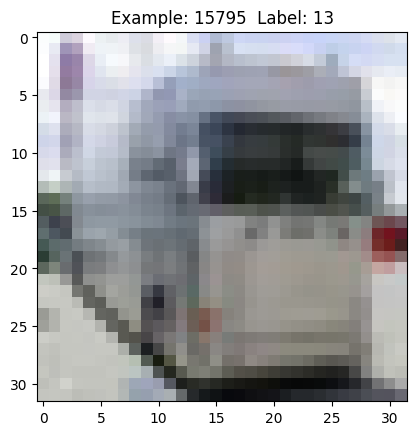

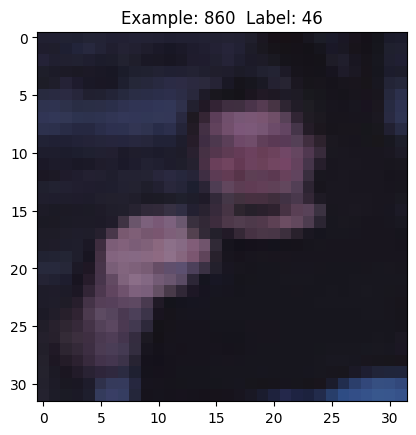

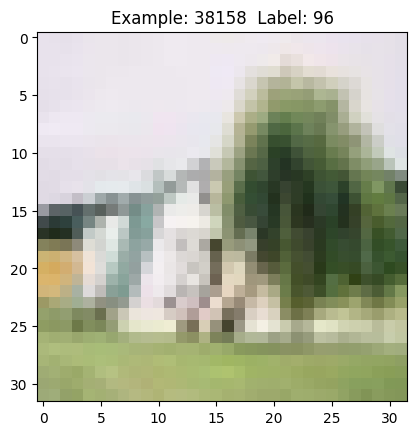

In [5]:
# Función auxiliar para visualizar datos de entrenamiento de manera aleatoria
def display_digit(num):
  image = x_train[num]
  label = y_train[num]
  # Mostrar
  plt.title('Example: %d  Label: %d' % (num, label))
  plt.imshow(image, cmap=plt.get_cmap('gray_r'))
  plt.show()

# Mostramos algunos ejemplos
display_digit(np.random.randint(0, x_train.shape[0]))
display_digit(np.random.randint(0, x_train.shape[0]))
display_digit(np.random.randint(0, x_train.shape[0]))

### **Estrategia 1: Red pre-entrenada**

###**Red 1: VGG16**

Como primera red pre-entrenada, elegimos VGG16 por considerarse simple y usar capas convolucionales estándar. Igualmente, aunque la arquitectura sea simple, parece ser pesada, por sus requerimientos de memoria (528MB según la documentación de Keras).

**Acondicionamos los datos de entrenamiento**

Imprimimos los valores mínimos y máximos antes de realizar cualquier cambio para tener una referencia de cómo cambiarán los datos tras el procesamiento

In [6]:
print('min:',x_train.min())
print('max:',x_train.max())


min: 0
max: 255


Realizamos OHE sobre las etiquetas de test y train.

In [7]:
print("Forma de y_train antes de la conversión:", y_train.shape)
print("Forma de y_test antes de la conversión:", y_test.shape)

Forma de y_train antes de la conversión: (50000, 1)
Forma de y_test antes de la conversión: (10000, 1)


In [8]:
# One-hot encoding
lb = LabelBinarizer()
y_train = lb.fit_transform(y_train)
y_test = lb.transform(y_test)

In [9]:
print("Forma de y_train después de la conversión:", y_train.shape)
print("Forma de y_test después de la conversión:", y_test.shape)

Forma de y_train después de la conversión: (50000, 100)
Forma de y_test después de la conversión: (10000, 100)


Importamos la arquitectura VGG16 y aplicamos el preprocesamiento  necesario específicamente para esta red neuronal.

In [10]:
from tensorflow.keras.applications import vgg16
from tensorflow.keras.applications.vgg16 import preprocess_input, VGG16
x_train = vgg16.preprocess_input(x_train)
x_test = vgg16.preprocess_input(x_test)

Comprobamos cómo han cambiado los datos tras el procesamiento.

In [11]:
print(x_train.max())
print(x_train.min())

151.061
-123.68


**Cargamos el base model**

In [15]:
base_model = vgg16.VGG16(weights='imagenet',
                 include_top=False, # No incluir el Top Model (parte destinada a la clasificación)
                 input_shape=(32,32,3))

base_model.trainable = False # Evitar que los pesos se modifiquen en la parte convolucional -> TRANSFER LEARNING
base_model.summary()

Model: "vgg16"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)           │ (None, 32, 32, 3)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block1_conv1 (Conv2D)                │ (None, 32, 32, 64)          │           1,792 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block1_conv2 (Conv2D)                │ (None, 32, 32, 64)          │          36,928 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block1_pool (MaxPooling2D)           │ (None, 16, 16, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block2_conv1 (Conv2D)                │ (None, 16, 16, 128)         │          73,856 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block2_conv2 (Conv2D)                │ (None, 16, 16, 128)         │         147,584 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block2_pool (MaxPooling2D)           │ (None, 8, 8, 128)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block3_conv1 (Conv2D)                │ (None, 8, 8, 256)           │         295,168 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block3_conv2 (Conv2D)                │ (None, 8, 8, 256)           │         590,080 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block3_conv3 (Conv2D)                │ (None, 8, 8, 256)           │         590,080 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block3_pool (MaxPooling2D)           │ (None, 4, 4, 256)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block4_conv1 (Conv2D)                │ (None, 4, 4, 512)           │       1,180,160 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block4_conv2 (Conv2D)                │ (None, 4, 4, 512)           │       2,359,808 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block4_conv3 (Conv2D)                │ (None, 4, 4, 512)           │       2,359,808 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block4_pool (MaxPooling2D)           │ (None, 2, 2, 512)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block5_conv1 (Conv2D)                │ (None, 2, 2, 512)           │       2,359,808 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block5_conv2 (Conv2D)                │ (None, 2, 2, 512)           │       2,359,808 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block5_conv3 (Conv2D)                │ (None, 2, 2, 512)           │       2,359,808 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block5_pool (MaxPooling2D)           │ (None, 1, 1, 512)           │               0 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 14,714,688 (56.13 MB)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 14,714,688 (56.13 MB)

Creamos un nuevo modelo secuencial y lo conectamos con nuestro base model. También añadimos más capas al nuevo modelo y observamos el resumen de nuestro "top model".

In [16]:
pre_trained_model = Sequential()
pre_trained_model.add(base_model)
pre_trained_model.add(layers.Flatten())
pre_trained_model.add(layers.Dense(512, activation='relu'))
pre_trained_model.add(layers.Dense(100, activation='softmax'))

#### **Transfer Learning**

**Congelando el modelo base y creando el top model**

Primero congelamos el base model, es decir, hacemos que sus pesos no se actualicen durante el entrenamiento

Capa input_layer_1 congelada...
Capa block1_conv1 congelada...
Capa block1_conv2 congelada...
Capa block1_pool congelada...
Capa block2_conv1 congelada...
Capa block2_conv2 congelada...
Capa block2_pool congelada...
Capa block3_conv1 congelada...
Capa block3_conv2 congelada...
Capa block3_conv3 congelada...
Capa block3_pool congelada...
Capa block4_conv1 congelada...
Capa block4_conv2 congelada...
Capa block4_conv3 congelada...
Capa block4_pool congelada...
Capa block5_conv1 congelada...
Capa block5_conv2 congelada...
Capa block5_conv3 congelada...
Capa block5_pool congelada...
[INFO]: Compilando el modelo...
[INFO]: Entrenando la red...
Epoch 1/15
313/313 ━━━━━━━━━━━━━━━━━━━━ 19s 34ms/step - accuracy: 0.0081 - loss: 25.9017 - val_accuracy: 0.0143 - val_loss: 19.2581 - learning_rate: 1.0000e-05
Epoch 2/15
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.0188 - loss: 18.2417 - val_accuracy: 0.0325 - val_loss: 15.6317 - learning_rate: 1.0000e-05
Epoch 3/15
313/313 ━━━━━━━━━━━━━━━━━

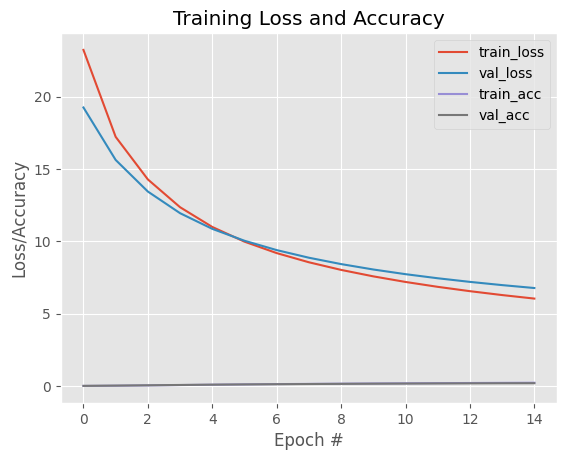

In [17]:
# Congelar las capas del modelo base VGG16
for layer in base_model.layers:
    layer.trainable = False
    print('Capa ' + layer.name + ' congelada...')

# Compilar el modelo
print("[INFO]: Compilando el modelo...")
pre_trained_model.compile(loss="categorical_crossentropy",
                          optimizer=Adam(learning_rate=0.00001),
                          metrics=["accuracy"])

early_stopping = EarlyStopping(monitor='val_accuracy', patience=5, restore_best_weights=True)
lr_scheduler = ReduceLROnPlateau(monitor='val_accuracy', factor=0.5, patience=3)

# Entrenamiento de la red
print("[INFO]: Entrenando la red...")
H_pre = pre_trained_model.fit(x_train,
                              y_train,
                              batch_size=128,
                              epochs=15,
                              validation_split=0.2,
                              callbacks=[early_stopping, lr_scheduler])

# Evaluación del modelo
print("[INFO]: Evaluando el modelo...")

# Efectuamos la predicción (empleamos el mismo valor de batch_size que en training)
predictions = pre_trained_model.predict(x_test,
                                        batch_size=128)

# Sacamos el report para test
print(classification_report(y_test.argmax(axis=1),
                            predictions.argmax(axis=1),
                            target_names=labelNames))

epochs = len(H_pre.history["loss"])

# Gráficas
plt.style.use("ggplot")
plt.figure()
plt.plot(np.arange(0, epochs), H_pre.history["loss"], label="train_loss")
plt.plot(np.arange(0, epochs), H_pre.history["val_loss"], label="val_loss")
plt.plot(np.arange(0, epochs), H_pre.history["accuracy"], label="train_acc")
plt.plot(np.arange(0, epochs), H_pre.history["val_accuracy"], label="val_acc")
plt.title("Training Loss and Accuracy")
plt.xlabel("Epoch #")
plt.ylabel("Loss/Accuracy")
plt.legend()
plt.show()

- Tanto train_loss como val_loss siguen una trayectoria muy similar, lo que indica que el modelo tiene un comportamiento coherente en los datos de entrenamiento y validación.  
- Ambas curvas disminuyen de manera constante, lo que sugiere que el modelo está mejorando en ambos conjuntos (entrenamiento y validación) sin señales claras de sobreajuste hasta ahora.  
-Al final de las épocas mostradas, la pérdida sigue disminuyendo en ambos conjuntos, lo que puede indicar que aún hay espacio para mejorar si se entrenara más.

- En este caso, las líneas de precisión (púrpura y negra) están pegadas al eje inferior (alrededor de 0), lo que indica que la precisión es extremadamente baja, casi nula, tanto para los datos de entrenamiento como de validación.
- Esto es un indicativo de que el modelo no está aprendiendo bien o tiene dificultades para captar patrones útiles del conjunto de datos.

Este gráfico sugiere que, aunque la pérdida está mejorando tanto en el entrenamiento como en la validación, el modelo tiene un rendimiento extremadamente bajo en términos de precisión. Esto indica que, aunque el modelo está aprendiendo algo, todavía no está capturando correctamente los patrones necesarios para clasificar el conjunto de datos CIFAR-100. Se recomiendan ajustes en la arquitectura, hiperparámetros, y preprocesamiento para mejorar los resultados.

# Red 2: XCEPTION.

In [26]:
# Cargar y preprocesar los datos CIFAR-100
(x_train, y_train), (x_test, y_test) = cifar100.load_data()

# CIFAR100 labelnames
labelNames = ['apple', 'aquarium_fish', 'baby', 'bear', 'beaver', 'bed', 'bee', 'beetle', 'bicycle', 'bottle', 'bowl', 'boy', 'bridge', 'bus', 'butterfly', 'camel', 'can', 'castle', 'caterpillar', 'cattle', 'chair', 'chimpanzee', 'clock', 'cloud', 'cockroach', 'couch', 'crab', 'crocodile', 'cup', 'dinosaur', 'dolphin', 'elephant', 'flatfish', 'forest', 'fox', 'girl', 'hamster', 'house', 'kangaroo', 'keyboard', 'lamp', 'lawn_mower', 'leopard', 'lion', 'lizard', 'lobster', 'man', 'maple_tree', 'motorcycle', 'mountain', 'mouse', 'mushroom', 'oak_tree', 'orange', 'orchid', 'otter', 'palm_tree', 'pear', 'pickup_truck', 'pine_tree', 'plain', 'plate', 'poppy', 'porcupine', 'possum', 'rabbit', 'raccoon', 'ray', 'road', 'rocket', 'rose', 'sea', 'seal', 'shark', 'shrew', 'skunk', 'skyscraper', 'snail', 'snake', 'spider', 'squirrel', 'streetcar', 'sunflower', 'sweet_pepper', 'table', 'tank', 'telephone', 'television', 'tiger', 'tractor', 'train', 'trout', 'tulip', 'turtle', 'wardrobe', 'whale', 'willow_tree', 'wolf', 'woman', 'worm']

In [27]:
# Redimensionar las imágenes a 96x96 para que coincidan con la entrada mínima requerida por Xception
x_train = tf.image.resize(x_train, (96, 96))
x_test = tf.image.resize(x_test, (96, 96))

# # Normalizar los datos
# x_train = tf.cast(x_train, tf.float32) / 255.0
# x_test = tf.cast(x_test, tf.float32) / 255.0

# Convertir las etiquetas a una codificación categórica
y_train = to_categorical(y_train, 100)
y_test = to_categorical(y_test, 100)


In [28]:
from tensorflow.keras.applications import xception
from tensorflow.keras.applications.xception import preprocess_input
x_train = xception.preprocess_input(x_train)
x_test = xception.preprocess_input(x_test)

In [29]:
base_model = xception.Xception(weights='imagenet',
                 include_top=False, # No incluir el Top Model (parte destinada a la clasificación)
                 input_shape=(96,96,3))

base_model.trainable = False # Evitar que los pesos se modifiquen en la parte convolucional -> TRANSFER LEARNING
base_model.summary()

Model: "xception"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)              ┃ Output Shape           ┃        Param # ┃ Connected to           ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━┩
│ input_layer_4             │ (None, 96, 96, 3)      │              0 │ -                      │
│ (InputLayer)              │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ block1_conv1 (Conv2D)     │ (None, 47, 47, 32)     │            864 │ input_layer_4[0][0]    │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ block1_conv1_bn           │ (None, 47, 47, 32)     │            128 │ block1_conv1[0][0]     │
│ (BatchNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ block1_conv1_act          │ (None, 47, 47, 32)     │              0 │ block1_conv1_bn[0][0]  │
│ (Activation)              │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ block1_conv2 (Conv2D)     │ (None, 45, 45, 64)     │         18,432 │ block1_conv1_act[0][0] │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ block1_conv2_bn           │ (None, 45, 45, 64)     │            256 │ block1_conv2[0][0]     │
│ (BatchNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ block1_conv2_act          │ (None, 45, 45, 64)     │              0 │ block1_conv2_bn[0][0]  │
│ (Activation)              │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ block2_sepconv1           │ (None, 45, 45, 128)    │          8,768 │ block1_conv2_act[0][0] │
│ (SeparableConv2D)         │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ block2_sepconv1_bn        │ (None, 45, 45, 128)    │            512 │ block2_sepconv1[0][0]  │
│ (BatchNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ block2_sepconv2_act       │ (None, 45, 45, 128)    │              0 │ block2_sepconv1_bn[0]… │
│ (Activation)              │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ block2_sepconv2           │ (None, 45, 45, 128)    │         17,536 │ block2_sepconv2_act[0… │
│ (SeparableConv2D)         │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ block2_sepconv2_bn        │ (None, 45, 45, 128)    │            512 │ block2_sepconv2[0][0]  │
│ (BatchNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2d_4 (Conv2D)         │ (None, 23, 23, 128)    │          8,192 │ block1_conv2_act[0][0] │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ block2_pool               │ (None, 23, 23, 128)    │              0 │ block2_sepconv2_bn[0]… │
│ (MaxPooling2D)            │                        │                │                        │
├──────────────────────

 Total params: 20,861,480 (79.58 MB)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 20,861,480 (79.58 MB)

In [30]:
# Crear el modelo completo
model = models.Sequential([
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dense(512, activation='relu'),
    layers.Dense(100, activation='softmax')
])

Capa input_layer_4 congelada...
Capa block1_conv1 congelada...
Capa block1_conv1_bn congelada...
Capa block1_conv1_act congelada...
Capa block1_conv2 congelada...
Capa block1_conv2_bn congelada...
Capa block1_conv2_act congelada...
Capa block2_sepconv1 congelada...
Capa block2_sepconv1_bn congelada...
Capa block2_sepconv2_act congelada...
Capa block2_sepconv2 congelada...
Capa block2_sepconv2_bn congelada...
Capa conv2d_4 congelada...
Capa block2_pool congelada...
Capa batch_normalization_4 congelada...
Capa add_12 congelada...
Capa block3_sepconv1_act congelada...
Capa block3_sepconv1 congelada...
Capa block3_sepconv1_bn congelada...
Capa block3_sepconv2_act congelada...
Capa block3_sepconv2 congelada...
Capa block3_sepconv2_bn congelada...
Capa conv2d_5 congelada...
Capa block3_pool congelada...
Capa batch_normalization_5 congelada...
Capa add_13 congelada...
Capa block4_sepconv1_act congelada...
Capa block4_sepconv1 congelada...
Capa block4_sepconv1_bn congelada...
Capa block4_sepco

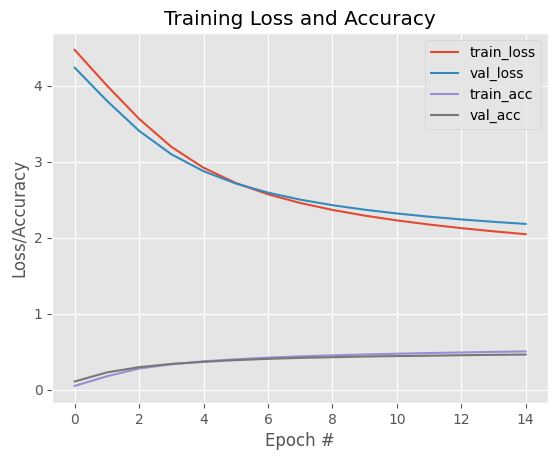

In [32]:
# Congelar las capas del modelo base Xception
for layer in base_model.layers:
    layer.trainable = False
    print('Capa ' + layer.name + ' congelada...')

# Compilar el modelo
print("[INFO]: Compilando el modelo...")
model.compile(loss="categorical_crossentropy",
                          optimizer=Adam(learning_rate=0.00001),
                          metrics=["accuracy"])

early_stopping = EarlyStopping(monitor='val_accuracy', patience=5, restore_best_weights=True)
lr_scheduler = ReduceLROnPlateau(monitor='val_accuracy', factor=0.5, patience=3)

# Entrenamiento de la red
print("[INFO]: Entrenando la red...")
H_pre = model.fit(x_train,
                              y_train,
                              batch_size=128,
                              epochs=15,
                              validation_split=0.2,
                              callbacks=[early_stopping, lr_scheduler])

# Evaluación del modelo
print("[INFO]: Evaluando el modelo...")

# Efectuamos la predicción (empleamos el mismo valor de batch_size que en training)
predictions = model.predict(x_test,
                                        batch_size=128)

# Sacamos el report para test
print(classification_report(y_test.argmax(axis=1),
                            predictions.argmax(axis=1),
                            target_names=labelNames))

epochs = len(H_pre.history["loss"])

# Gráficas
plt.style.use("ggplot")
plt.figure()
plt.plot(np.arange(0, epochs), H_pre.history["loss"], label="train_loss")
plt.plot(np.arange(0, epochs), H_pre.history["val_loss"], label="val_loss")
plt.plot(np.arange(0, epochs), H_pre.history["accuracy"], label="train_acc")
plt.plot(np.arange(0, epochs), H_pre.history["val_accuracy"], label="val_acc")
plt.title("Training Loss and Accuracy")
plt.xlabel("Epoch #")
plt.ylabel("Loss/Accuracy")
plt.legend()
plt.show()

Con el modelo Xception (accuracy: 0,47) hemos conseguido aumentar el accuracy en la predicción con respecto al modelo VGG16 (accuracy: 0,26).
Elegimos el modelo Xception al obtener un mejor resultado para aplicarle fine tuning y ver si se puede mejorar.  

FINE TUNING

Capa input_layer_6 congelada...
Capa block1_conv1 congelada...
Capa block1_conv1_bn congelada...
Capa block1_conv1_act congelada...
Capa block1_conv2 congelada...
Capa block1_conv2_bn congelada...
Capa block1_conv2_act congelada...
Capa block2_sepconv1 congelada...
Capa block2_sepconv1_bn congelada...
Capa block2_sepconv2_act congelada...
Capa block2_sepconv2 congelada...
Capa block2_sepconv2_bn congelada...
Capa conv2d_8 congelada...
Capa block2_pool congelada...
Capa batch_normalization_8 congelada...
Capa add_24 congelada...
Capa block3_sepconv1_act congelada...
Capa block3_sepconv1 congelada...
Capa block3_sepconv1_bn congelada...
Capa block3_sepconv2_act congelada...
Capa block3_sepconv2 congelada...
Capa block3_sepconv2_bn congelada...
Capa conv2d_9 congelada...
Capa block3_pool congelada...
Capa batch_normalization_9 congelada...
Capa add_25 congelada...
Capa block4_sepconv1_act congelada...
Capa block4_sepconv1 congelada...
Capa block4_sepconv1_bn congelada...
Capa block4_sepco

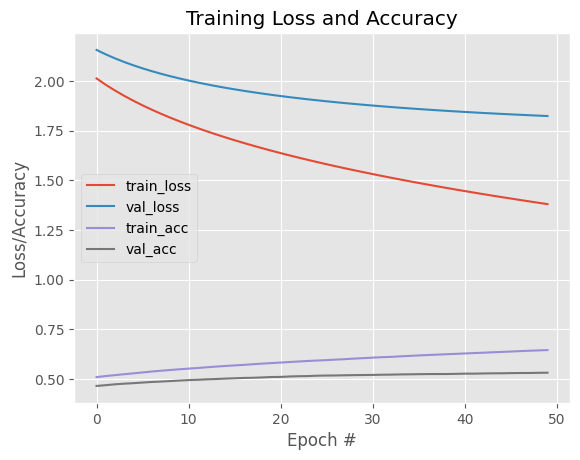

In [34]:
# Volvemos a cargar el base_model
base_model = xception.Xception(weights='imagenet',
                 include_top=False, # No incluir el Top Model (parte destinada a la clasificación)
                 input_shape=(96, 96, 3))

# Congelamos las capas deseadas
for layer in base_model.layers:
  if layer.name == 'block_16_expand':
    break
  layer.trainable = False
  print('Capa ' + layer.name + ' congelada...')

# Compilar el modelo
print("[INFO]: Compilando el modelo...")
model.compile(loss="categorical_crossentropy",
                          optimizer=Adam(learning_rate=0.00001),
                          metrics=["accuracy"])

early_stopping = EarlyStopping(monitor='val_accuracy', patience=5, restore_best_weights=True)
lr_scheduler = ReduceLROnPlateau(monitor='val_accuracy', factor=0.5, patience=3)

# Volvemos a entrenar la red
print("[INFO]: Entrenando la red...")
H_pre = model.fit(x_train,
                              y_train,
                              epochs=50,
                              batch_size=128,
                              validation_split=0.2,
                              callbacks=[early_stopping, lr_scheduler]
                              )

# Evaluación del modelo
print("[INFO]: Evaluando el modelo...")

# Efectuamos la predicción (empleamos el mismo valor de batch_size que en training)
predictions = model.predict(x_test,
                                        batch_size=128)

# Sacamos el report para test
print(classification_report(y_test.argmax(axis=1),
                            predictions.argmax(axis=1),
                            target_names=labelNames))

epochs = len(H_pre.history["loss"])

# Gráficas
plt.style.use("ggplot")
plt.figure()
plt.plot(np.arange(0, epochs), H_pre.history["loss"], label="train_loss")
plt.plot(np.arange(0, epochs), H_pre.history["val_loss"], label="val_loss")
plt.plot(np.arange(0, epochs), H_pre.history["accuracy"], label="train_acc")
plt.plot(np.arange(0, epochs), H_pre.history["val_accuracy"], label="val_acc")
plt.title("Training Loss and Accuracy")
plt.xlabel("Epoch #")
plt.ylabel("Loss/Accuracy")
plt.legend()
plt.show()

Con el fine tuning sobre el modelo Xception (el de mejor resultado) obtenemos un accuracy de 0,53 por lo que hemos conseguido mejorarlo.

In [40]:
%whos

Variable                Type                 Data/Info
------------------------------------------------------
Activation              type                 <class 'keras.src.layers.<...>s.activation.Activation'>
Adam                    type                 <class 'keras.src.optimizers.adam.Adam'>
BASE_FOLDER             str                  /content/DL
BatchNormalization      type                 <class 'keras.src.layers.<...>tion.BatchNormalization'>
Conv2D                  type                 <class 'keras.src.layers.<...>olutional.conv2d.Conv2D'>
Dense                   type                 <class 'keras.src.layers.core.dense.Dense'>
Dropout                 type                 <class 'keras.src.layers.<...>ization.dropout.Dropout'>
EarlyStopping           type                 <class 'keras.src.callbac<...>_stopping.EarlyStopping'>
Flatten                 type                 <class 'keras.src.layers.<...>shaping.flatten.Flatten'>
H_pre                   History              <keras.

In [41]:
del x_test, x_train, y_test, y_train # Eliminamos variables para liberar espacio en memoria RAM.

### **Estrategia 2: Entrenar desde cero o from scratch**

#### **- Definición de las funciones de entrenamiento**

#### **- Cargando el conjunto de datos**

In [114]:
# Carga de datos
print("[INFO]: Loading CIFAR-100 data...")
cifar_100 = tf.keras.datasets.cifar100
((x_train, y_train), (x_test, y_test)) = cifar100.load_data()

# CIFAR100 labelnames
labelNames = ['apple', 'aquarium_fish', 'baby', 'bear', 'beaver', 'bed', 'bee', 'beetle', 'bicycle', 'bottle', 'bowl', 'boy', 'bridge', 'bus', 'butterfly', 'camel', 'can', 'castle', 'caterpillar', 'cattle', 'chair', 'chimpanzee', 'clock', 'cloud', 'cockroach', 'couch', 'crab', 'crocodile', 'cup', 'dinosaur', 'dolphin', 'elephant', 'flatfish', 'forest', 'fox', 'girl', 'hamster', 'house', 'kangaroo', 'keyboard', 'lamp', 'lawn_mower', 'leopard', 'lion', 'lizard', 'lobster', 'man', 'maple_tree', 'motorcycle', 'mountain', 'mouse', 'mushroom', 'oak_tree', 'orange', 'orchid', 'otter', 'palm_tree', 'pear', 'pickup_truck', 'pine_tree', 'plain', 'plate', 'poppy', 'porcupine', 'possum', 'rabbit', 'raccoon', 'ray', 'road', 'rocket', 'rose', 'sea', 'seal', 'shark', 'shrew', 'skunk', 'skyscraper', 'snail', 'snake', 'spider', 'squirrel', 'streetcar', 'sunflower', 'sweet_pepper', 'table', 'tank', 'telephone', 'television', 'tiger', 'tractor', 'train', 'trout', 'tulip', 'turtle', 'wardrobe', 'whale', 'willow_tree', 'wolf', 'woman', 'worm']


[INFO]: Loading CIFAR-100 data...


In [116]:
np.random.seed(42)
tf.random.set_seed(42)
random.seed(42)

In [117]:
path = BASE_FOLDER

os.chdir(path)

folders = os.listdir()
folder_paths = []
all_images = []
all_classes = []
img_size = 128

#### **- Inspeccionando el conjunto de datos**

<module 'keras.api.datasets.cifar100' from '/usr/local/lib/python3.10/dist-packages/keras/api/datasets/cifar100/__init__.py'>
100


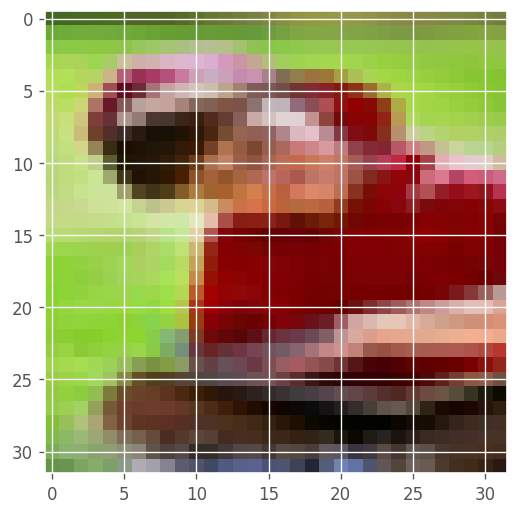

La clase es boy


In [111]:
print(cifar_100)
print(len(labelNames))

# show image
i = 7313 # 5000 # 9144
imgplot = plt.imshow(x_train[i])
plt.show()
print("La clase es %s" %(labelNames[y_train[i][0]]))

['apple', 'aquarium_fish', 'baby', 'bear', 'beaver', 'bed', 'bee', 'beetle', 'bicycle', 'bottle', 'bowl', 'boy', 'bridge', 'bus', 'butterfly', 'camel', 'can', 'castle', 'caterpillar', 'cattle', 'chair', 'chimpanzee', 'clock', 'cloud', 'cockroach', 'couch', 'crab', 'crocodile', 'cup', 'dinosaur', 'dolphin', 'elephant', 'flatfish', 'forest', 'fox', 'girl', 'hamster', 'house', 'kangaroo', 'keyboard', 'lamp', 'lawn_mower', 'leopard', 'lion', 'lizard', 'lobster', 'man', 'maple_tree', 'motorcycle', 'mountain', 'mouse', 'mushroom', 'oak_tree', 'orange', 'orchid', 'otter', 'palm_tree', 'pear', 'pickup_truck', 'pine_tree', 'plain', 'plate', 'poppy', 'porcupine', 'possum', 'rabbit', 'raccoon', 'ray', 'road', 'rocket', 'rose', 'sea', 'seal', 'shark', 'shrew', 'skunk', 'skyscraper', 'snail', 'snake', 'spider', 'squirrel', 'streetcar', 'sunflower', 'sweet_pepper', 'table', 'tank', 'telephone', 'television', 'tiger', 'tractor', 'train', 'trout', 'tulip', 'turtle', 'wardrobe', 'whale', 'willow_tree',

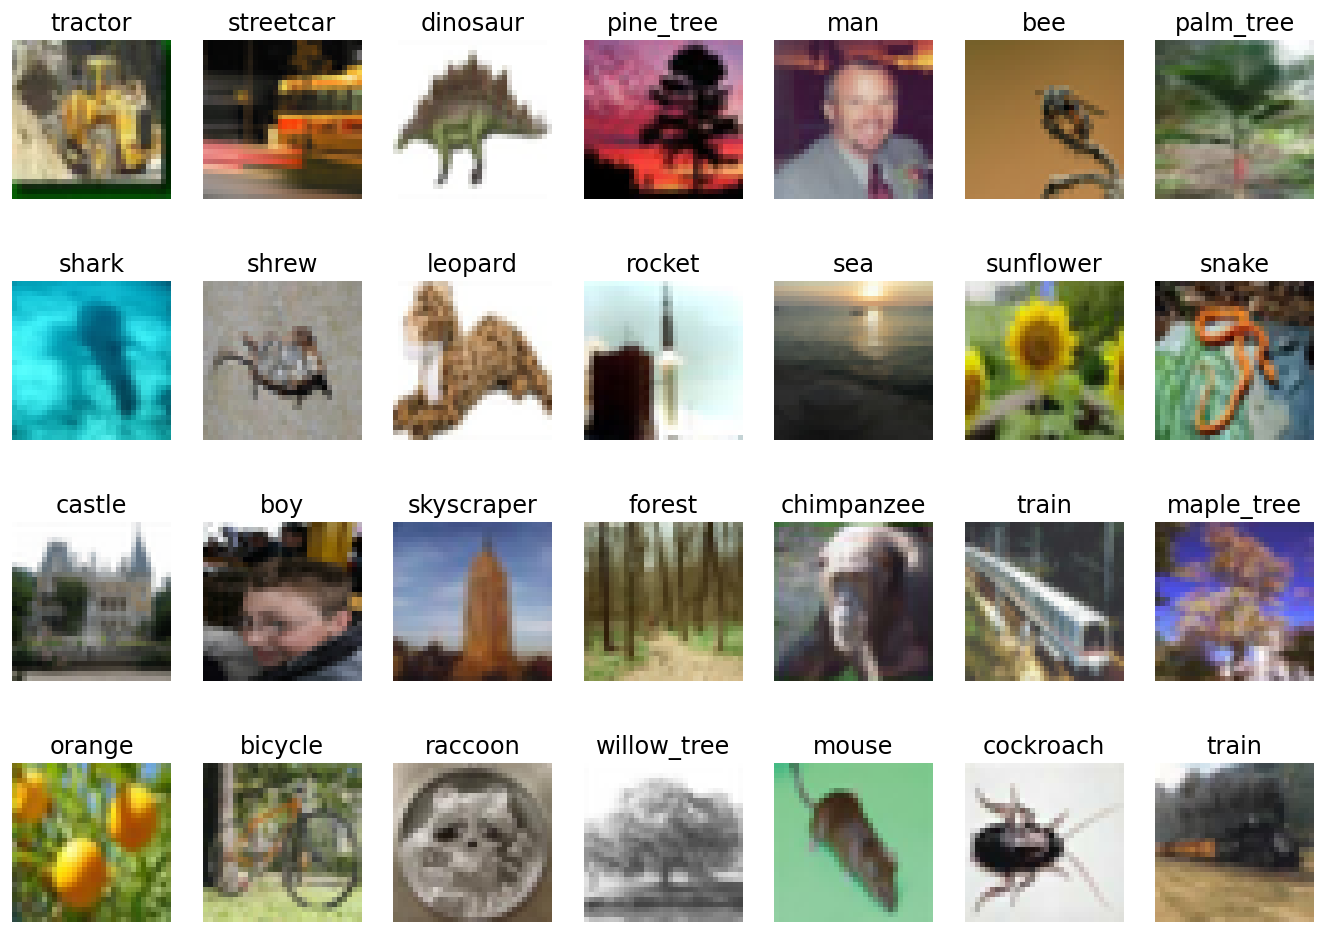

In [113]:
fig = plt.figure(figsize=(14,10))

for n, i in enumerate(random.sample(range(1,len(labelNames)), 28)):
    fig.add_subplot(4, 7, n+1)
    img = x_train[i]
    plt.imshow(img)
    plt.title(labelNames[y_train[i][0]])
    plt.axis('off')

print(labelNames)

[Text(0.5, 1.0, 'Número de muestras por clase'),
 Text(0, 0.5, 'Número de muestras')]

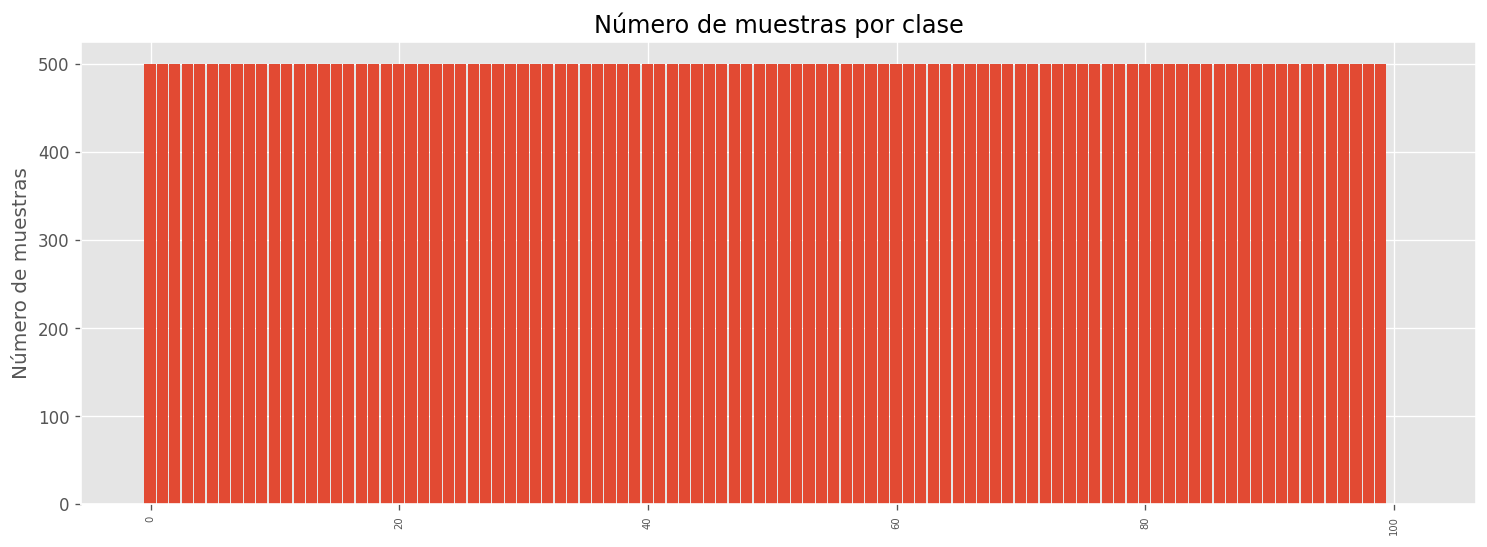

In [103]:
plt.rcParams.update({'figure.figsize':(15,5), 'figure.dpi':120})

# Plot Histogram on x
plt.hist(y_train, bins=range(0,103), width=0.9, align='left')
plt.xticks(rotation = 90, size=6)
plt.gca().set(title='Número de muestras por clase', ylabel='Número de muestras')

Vemos que el data set es balanceado para para las labels, siendo el número de imagenes para cada etiqueta 500.

#### **- Acondicionando el conjunto de datos**

In [104]:
print(x_train.shape)
print(x_test.shape)
print(y_train.shape)
print(y_test.shape)

(50000, 32, 32, 3)
(10000, 32, 32, 3)
(50000, 1)
(10000, 1)


In [118]:
# Transformación de datos categóricos OHE (etiquetas)
y_train = to_categorical(y_train, num_classes=100)
y_test = to_categorical(y_test, num_classes=100)

In [106]:
print(x_train.shape)
print(x_test.shape)
print(y_train.shape)
print(y_test.shape)

(50000, 32, 32, 3)
(10000, 32, 32, 3)
(50000, 100)
(10000, 100)


## 1º diseño de la arquitectura** (Accuracy = 53%, 2.957.188 parámetros entrenables)

Model: "functional_14"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ input_layer_19 (InputLayer)          │ (None, 32, 32, 3)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_260 (Conv2D)                  │ (None, 32, 32, 32)          │             896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_272              │ (None, 32, 32, 32)          │             128 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_261 (Conv2D)                  │ (None, 32, 32, 32)          │           9,248 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_273              │ (None, 32, 32, 32)          │             128 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_28 (MaxPooling2D)      │ (None, 16, 16, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_24 (Dropout)                 │ (None, 16, 16, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_262 (Conv2D)                  │ (None, 16, 16, 64)          │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_274              │ (None, 16, 16, 64)          │             256 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_263 (Conv2D)                  │ (None, 16, 16, 64)          │          36,928 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_275              │ (None, 16, 16, 64)          │             256 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_29 (MaxPooling2D)      │ (None, 8, 8, 64)            │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_25 (Dropout)                 │ (None, 8, 8, 64)            │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_264 (Conv2D)                  │ (None, 8, 8, 256)           │         147,712 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_276              │ (None, 8, 8, 256)           │           1,024 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_265 (Conv2D)                  │ (None, 8, 8, 256)           │         590,080 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_277              │ (None, 8, 8, 256)           │           1,024 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_30 (MaxPooling2D)      │ (None, 4, 4, 256)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼──────────────

 Total params: 2,957,188 (11.28 MB)

 Trainable params: 2,954,756 (11.27 MB)

 Non-trainable params: 2,432 (9.50 KB)

[INFO]: Compilando el modelo...
[INFO]: Entrenando la red...
Epoch 1/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 16s 23ms/step - accuracy: 0.0634 - loss: 4.7930 - val_accuracy: 0.1659 - val_loss: 3.5850
Epoch 2/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.1741 - loss: 3.6092 - val_accuracy: 0.2669 - val_loss: 3.0220
Epoch 3/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.2594 - loss: 3.0786 - val_accuracy: 0.3206 - val_loss: 2.7222
Epoch 4/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.3302 - loss: 2.6762 - val_accuracy: 0.3861 - val_loss: 2.4195
Epoch 5/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.3745 - loss: 2.4049 - val_accuracy: 0.4206 - val_loss: 2.2475
Epoch 6/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.4244 - loss: 2.1937 - val_accuracy: 0.4305 - val_loss: 2.2491
Epoch 7/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.4638 - loss: 2.0138 - val_accuracy: 0.4514 - val_loss: 2.1328
Epoch 8/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 2

[INFO]: Evaluando el modelo...
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step
               precision    recall  f1-score   support

        apple       0.70      0.81      0.75       100
aquarium_fish       0.66      0.57      0.61       100
         baby       0.39      0.51      0.44       100
         bear       0.23      0.30      0.26       100
       beaver       0.36      0.34      0.35       100
          bed       0.50      0.56      0.53       100
          bee       0.65      0.51      0.57       100
       beetle       0.64      0.50      0.56       100
      bicycle       0.74      0.71      0.72       100
       bottle       0.77      0.63      0.69       100
         bowl       0.56      0.44      0.49       100
          boy       0.27      0.33      0.29       100
       bridge       0.71      0.53      0.61       100
          bus       0.55      0.38      0.45       100
    butterfly       0.65      0.33      0.44       100
        camel       0.34      0.59      0.43     

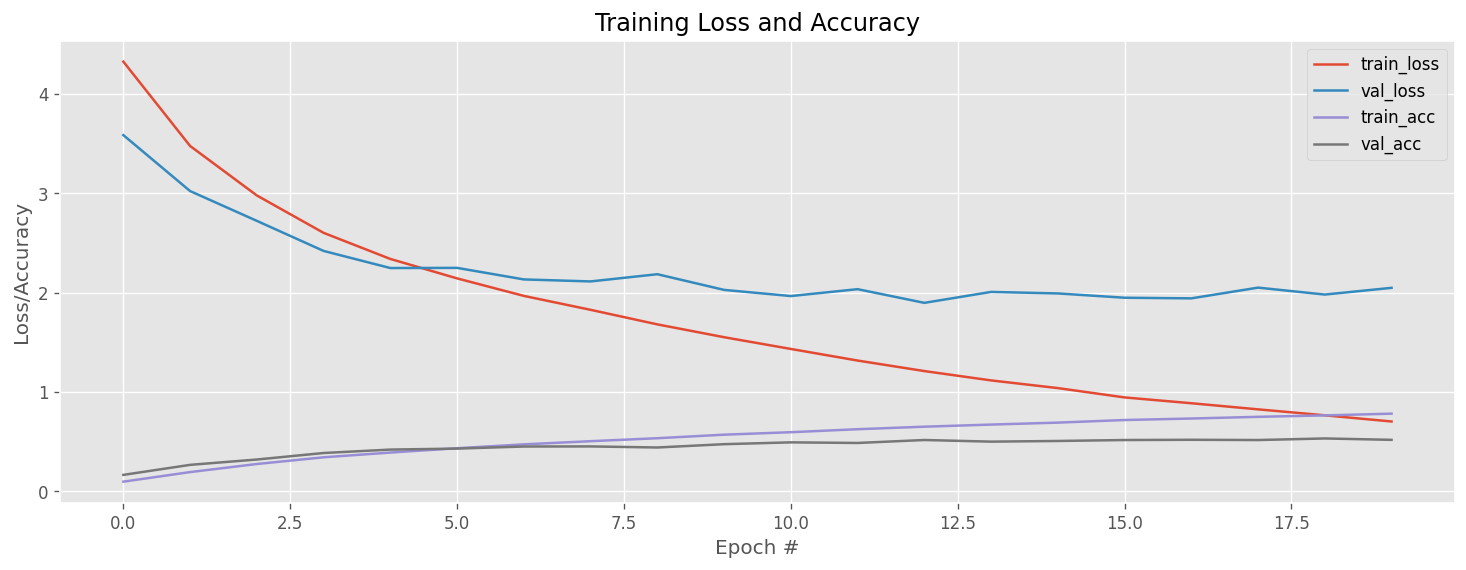

In [107]:
# ---------------------------------------------------------------------
# BASE MODEL -> extrae las características de las imágenes

# Definimos entradas
inputs = Input(shape=(x_train.shape[1], x_train.shape[2], x_train.shape[3]))

# Primer set de capas CONV => RELU => CONV => RELU => POOL
x1 = Conv2D(32, (3, 3), padding="same", activation="relu")(inputs)
x1 = BatchNormalization()(x1)
x1 = Conv2D(32, (3, 3), padding="same", activation="relu")(x1)
x1 = BatchNormalization()(x1)
x1 = MaxPooling2D(pool_size=(2, 2))(x1)
x1 = Dropout(0.25)(x1)

# Segundo set de capas CONV => RELU => CONV => RELU => POOL
x2 = Conv2D(64, (3, 3), padding="same", activation="relu")(x1)
x2 = BatchNormalization()(x2)
x2 = Conv2D(64, (3, 3), padding="same", activation="relu")(x2)
x2 = BatchNormalization()(x2)
x2 = MaxPooling2D(pool_size=(2, 2))(x2)
x2 = Dropout(0.25)(x2)

# Tercer set de capas CONV => RELU => CONV => RELU => POOL
x2 = Conv2D(256, (3, 3), padding="same", activation="relu")(x2)
x2 = BatchNormalization()(x2)
x2 = Conv2D(256, (3, 3), padding="same", activation="relu")(x2)
x2 = BatchNormalization()(x2)
x2 = MaxPooling2D(pool_size=(2, 2))(x2)
x2 = Dropout(0.25)(x2)
# ---------------------------------------------------------------------------

# ---------------------------------------------------------------------------
# TOP MODEL -> encargada de separar entre clases, hacer la clasificación

# Primer (y único) set de capas FC => RELU
xfc = Flatten()(x2)
xfc = Dense(512, activation="relu")(xfc)
xfc = BatchNormalization()(xfc)
xfc = Dropout(0.5)(xfc)

# Clasificador softmax
predictions = Dense(100, activation="softmax")(xfc)
# ---------------------------------------------------------------------------

#Creamos el modelo
model = Model(inputs=inputs, outputs=predictions)

# Entrenando la solución
train(x_train, y_train, x_test, y_test, model, BASE_FOLDER)

Vemos que el modelo tiene un accuracy de 0,53 pero tiene muchos parámetros entrenables que intentaremos reducir.

## 2º diseño de la arquitectura** (Accuracy = 16%,  365,860 parámetros entrenables)

Cambiamos arquitectura añadiendo capas.

Model: "functional_11"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ input_layer_16 (InputLayer)          │ (None, 32, 32, 3)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_176 (Conv2D)                  │ (None, 32, 32, 64)          │           1,792 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_185              │ (None, 32, 32, 64)          │             256 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_177 (Conv2D)                  │ (None, 32, 32, 64)          │          36,928 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_186              │ (None, 32, 32, 64)          │             256 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_178 (Conv2D)                  │ (None, 32, 32, 64)          │          36,928 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_187              │ (None, 32, 32, 64)          │             256 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_179 (Conv2D)                  │ (None, 32, 32, 64)          │          36,928 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_188              │ (None, 32, 32, 64)          │             256 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_22 (MaxPooling2D)      │ (None, 16, 16, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_180 (Conv2D)                  │ (None, 16, 16, 32)          │          18,464 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_189              │ (None, 16, 16, 32)          │             128 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_181 (Conv2D)                  │ (None, 16, 16, 32)          │           9,248 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_190              │ (None, 16, 16, 32)          │             128 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_182 (Conv2D)                  │ (None, 16, 16, 32)          │           9,248 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_191              │ (None, 16, 16, 32)          │             128 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_183 (Conv2D)                  │ (None, 16, 16, 32)          │           9,248 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_192              │ (None, 16, 16, 32)          │             1

 Total params: 365,860 (1.40 MB)

 Trainable params: 363,716 (1.39 MB)

 Non-trainable params: 2,144 (8.38 KB)

[INFO]: Compilando el modelo...
[INFO]: Entrenando la red...
Epoch 1/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 44s 60ms/step - accuracy: 0.0113 - loss: 5.7221 - val_accuracy: 0.0181 - val_loss: 4.7201
Epoch 2/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/step - accuracy: 0.0157 - loss: 4.8769 - val_accuracy: 0.0186 - val_loss: 4.6573
Epoch 3/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/step - accuracy: 0.0170 - loss: 4.7590 - val_accuracy: 0.0254 - val_loss: 4.6471
Epoch 4/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/step - accuracy: 0.0187 - loss: 4.6655 - val_accuracy: 0.0270 - val_loss: 4.4915
Epoch 5/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/step - accuracy: 0.0210 - loss: 4.5889 - val_accuracy: 0.0327 - val_loss: 4.4700
Epoch 6/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/step - accuracy: 0.0310 - loss: 4.4958 - val_accuracy: 0.0386 - val_loss: 4.4350
Epoch 7/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/step - accuracy: 0.0368 - loss: 4.3833 - val_accuracy: 0.0474 - val_loss: 4.3480
Epoch 8/20
313/313 ━━━━━━━━━━━━━━━━

[INFO]: Evaluando el modelo...
79/79 ━━━━━━━━━━━━━━━━━━━━ 4s 21ms/step
               precision    recall  f1-score   support

        apple       0.17      0.32      0.23       100
aquarium_fish       0.13      0.16      0.15       100
         baby       0.10      0.15      0.12       100
         bear       0.07      0.09      0.08       100
       beaver       0.00      0.00      0.00       100
          bed       0.10      0.18      0.12       100
          bee       0.07      0.05      0.06       100
       beetle       0.10      0.14      0.11       100
      bicycle       0.13      0.03      0.05       100
       bottle       0.15      0.19      0.17       100
         bowl       0.00      0.00      0.00       100
          boy       0.04      0.02      0.03       100
       bridge       0.23      0.07      0.11       100
          bus       0.17      0.04      0.06       100
    butterfly       0.05      0.04      0.05       100
        camel       0.11      0.09      0.10    

/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1471: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1471: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1471: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


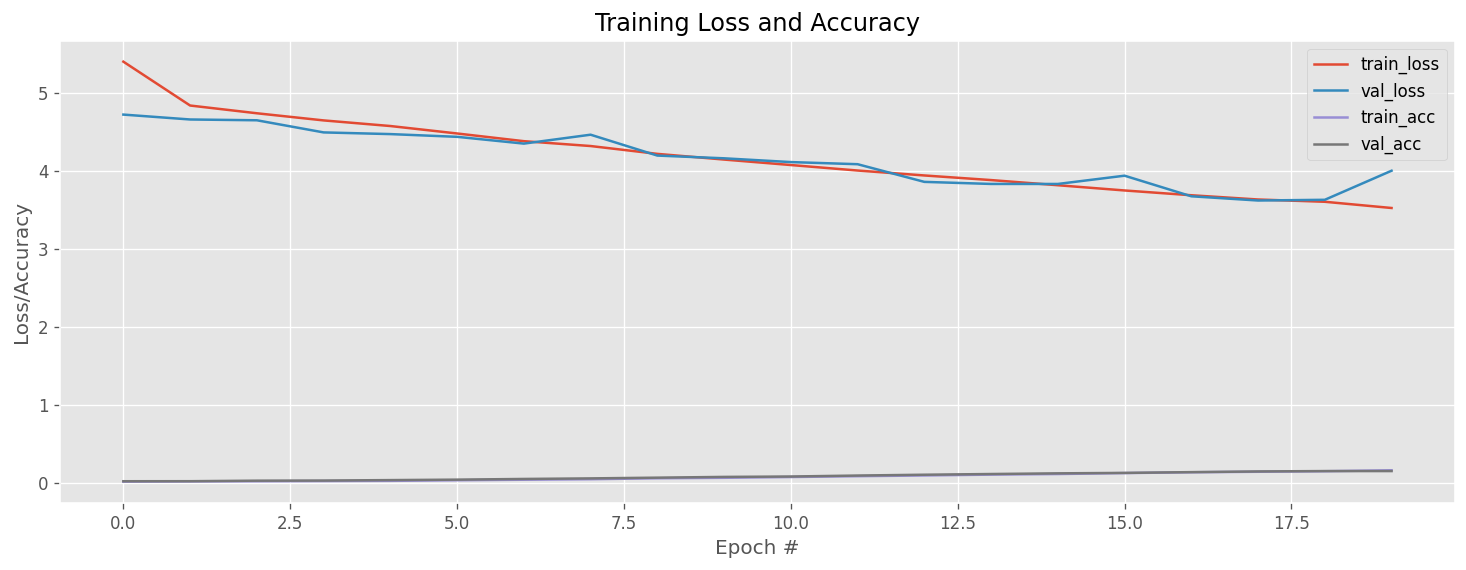

In [93]:
# ---------------------------------------------------------------------
# BASE MODEL -> extrae las características de las imágenes

# Definimos entradas
inputs = Input(shape=(x_train.shape[1], x_train.shape[2], x_train.shape[3]))

# 1 set de capas CONV => RELU => CONV => RELU => POOL
x1 = Conv2D(64, (3, 3), padding="same", activation="relu")(inputs)
x1 = BatchNormalization()(x1)
x1 = Conv2D(64, (3, 3), padding="same", activation="relu")(x1)
x1 = BatchNormalization()(x1)
# x1 = MaxPooling2D(pool_size=(2, 2))(x1)
# x1 = Dropout(0.25)(x1)

# 2 set de capas CONV => RELU => CONV => RELU => POOL
x2 = Conv2D(64, (3, 3), padding="same", activation="relu")(x1)
x2 = BatchNormalization()(x2)
x2 = Conv2D(64, (3, 3), padding="same", activation="relu")(x2)
x2 = BatchNormalization()(x2)
x2 = MaxPooling2D(pool_size=(2, 2))(x2)
# x2 = Dropout(0.25)(x2)


# 3 set de capas CONV => RELU => CONV => RELU => POOL
x3 = Conv2D(32, (3, 3), padding="same", activation="relu")(x2)
x3 = BatchNormalization()(x3)
x3 = Conv2D(32, (3, 3), padding="same", activation="relu")(x3)
x3 = BatchNormalization()(x3)
# x3 = MaxPooling2D(pool_size=(2, 2))(x3)
# x3 = Dropout(0.25)(x3)

# 4 set de capas CONV => RELU => CONV => RELU => POOL
x4 = Conv2D(32, (3, 3), padding="same", activation="relu")(x3)
x4 = BatchNormalization()(x4)
x4 = Conv2D(32, (3, 3), padding="same", activation="relu")(x4)
x4 = BatchNormalization()(x4)
x4 = MaxPooling2D(pool_size=(2, 2))(x4)
# x4 = Dropout(0.25)(x4)


# 5 set de capas CONV => RELU => CONV => RELU => POOL
x5 = Conv2D(16, (3, 3), padding="same", activation="relu")(x4)
x5 = BatchNormalization()(x5)
x5 = Conv2D(16, (3, 3), padding="same", activation="relu")(x5)
x5 = BatchNormalization()(x5)
# x5 = MaxPooling2D(pool_size=(2, 2))(x5)
# x5 = Dropout(0.25)(x5)

# 6 set de capas CONV => RELU => CONV => RELU => POOL
x6 = Conv2D(16, (3, 3), padding="same", activation="relu")(x5)
x6 = BatchNormalization()(x6)
x6 = Conv2D(16, (3, 3), padding="same", activation="relu")(x6)
x6 = BatchNormalization()(x6)
# x6 = MaxPooling2D(pool_size=(2, 2))(x6)
# x6 = Dropout(0.25)(x6)


# 7 set de capas CONV => RELU => CONV => RELU => POOL
x7 = Conv2D(8, (3, 3), padding="same", activation="relu")(x6)
x7 = BatchNormalization()(x7)
x7 = Conv2D(8, (3, 3), padding="same", activation="relu")(x7)
x7 = BatchNormalization()(x7)
# x7 = MaxPooling2D(pool_size=(2, 2))(x5)
# x7 = Dropout(0.25)(x7)

# 8 set de capas CONV => RELU => CONV => RELU => POOL
x8 = Conv2D(8, (3, 3), padding="same", activation="relu")(x7)
x8 = BatchNormalization()(x8)
x8 = Conv2D(8, (3, 3), padding="same", activation="relu")(x8)
x8 = BatchNormalization()(x8)
# x8 = MaxPooling2D(pool_size=(2, 2))(x8)
# x8 = Dropout(0.25)(x6)

# 9 set de capas CONV => RELU => CONV => RELU => POOL
x8 = Conv2D(8, (3, 3), padding="same", activation="relu")(x8)
x8 = BatchNormalization()(x8)
x8 = Conv2D(8, (3, 3), padding="same", activation="relu")(x8)
x8 = BatchNormalization()(x8)
# x8 = MaxPooling2D(pool_size=(2, 2))(x8)
# x8 = Dropout(0.25)(x8)

# 10 set de capas CONV => RELU => CONV => RELU => POOL
x8 = Conv2D(8, (3, 3), padding="same", activation="relu")(x8)
x8 = BatchNormalization()(x8)
x8 = Conv2D(8, (3, 3), padding="same", activation="relu")(x8)
x8 = BatchNormalization()(x8)
# x8 = MaxPooling2D(pool_size=(2, 2))(x8)
# x8 = Dropout(0.25)(x8)

# 11 set de capas CONV => RELU => CONV => RELU => POOL
x8 = Conv2D(8, (3, 3), padding="same", activation="relu")(x8)
x8 = BatchNormalization()(x8)
x8 = Conv2D(8, (3, 3), padding="same", activation="relu")(x8)
x8 = BatchNormalization()(x8)
# x8 = MaxPooling2D(pool_size=(2, 2))(x8)
# x8 = Dropout(0.25)(x8)

# 12 set de capas CONV => RELU => CONV => RELU => POOL
x8 = Conv2D(8, (3, 3), padding="same", activation="relu")(x8)
x8 = BatchNormalization()(x8)
x8 = Conv2D(8, (3, 3), padding="same", activation="relu")(x8)
x8 = BatchNormalization()(x8)
# x8 = MaxPooling2D(pool_size=(2, 2))(x8)
# x8 = Dropout(0.25)(x8)


# 13 set de capas CONV => RELU => CONV => RELU => POOL
x9 = Conv2D(4, (3, 3), padding="same", activation="relu")(x8)
x9 = BatchNormalization()(x9)
x9 = Conv2D(4, (3, 3), padding="same", activation="relu")(x9)
x9 = BatchNormalization()(x9)
# x9 = MaxPooling2D(pool_size=(2, 2))(x9)
# x9 = Dropout(0.25)(x9)

# 14 set de capas CONV => RELU => CONV => RELU => POOL
x10 = Conv2D(4, (3, 3), padding="same", activation="relu")(x9)
x10 = BatchNormalization()(x10)
x10 = Conv2D(4, (3, 3), padding="same", activation="relu")(x10)
x10 = BatchNormalization()(x10)
# x10 = MaxPooling2D(pool_size=(2, 2))(x10)
# x10 = Dropout(0.25)(x10)

# ---------------------------------------------------------------------------

# ---------------------------------------------------------------------------
# TOP MODEL -> encargada de separar entre clases, hacer la clasificación

# Primer (y único) set de capas FC => RELU
xfc = Flatten()(x10)
xfc = Dense(512, activation="relu")(xfc)
xfc = BatchNormalization()(xfc)
xfc = Dropout(0.5)(xfc)

# Clasificador softmax
predictions = Dense(100, activation="softmax")(xfc)
# ---------------------------------------------------------------------------

#Creamos el modelo
model = Model(inputs=inputs, outputs=predictions)

# Entrenando la solución con data augmentation
train(x_train, y_train, x_test, y_test, model, BASE_FOLDER)

Vemos que va muy bien porque se reducen mucho los parámetros entrenables.  
Sin embargo se reduce el accuracy.

## 3º diseño de la arquitectura** (Accuracy = 16%,  549,636 parámetros entrenables)

Probamos a aumentar la profundidad de la arquitectura pero vemos que no mejora en parámetros entrenables ni en accuracy. Eliminamos el código por uso de memoria.

## 4º diseño de la arquitectura** (Accuracy = 25%,  677,444 parámetros entrenables)

Reducimos la profundidad de la arquitectura.

Model: "functional_13"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ input_layer_18 (InputLayer)          │ (None, 32, 32, 3)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_236 (Conv2D)                  │ (None, 32, 32, 64)          │           1,792 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_247              │ (None, 32, 32, 64)          │             256 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_237 (Conv2D)                  │ (None, 32, 32, 64)          │          36,928 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_248              │ (None, 32, 32, 64)          │             256 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_238 (Conv2D)                  │ (None, 32, 32, 64)          │          36,928 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_249              │ (None, 32, 32, 64)          │             256 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_239 (Conv2D)                  │ (None, 32, 32, 64)          │          36,928 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_250              │ (None, 32, 32, 64)          │             256 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_240 (Conv2D)                  │ (None, 32, 32, 64)          │          36,928 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_251              │ (None, 32, 32, 64)          │             256 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_241 (Conv2D)                  │ (None, 32, 32, 64)          │          36,928 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_252              │ (None, 32, 32, 64)          │             256 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_242 (Conv2D)                  │ (None, 32, 32, 64)          │          36,928 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_253              │ (None, 32, 32, 64)          │             256 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_243 (Conv2D)                  │ (None, 32, 32, 64)          │          36,928 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_254              │ (None, 32, 32, 64)          │             256 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼──────────────

 Total params: 677,444 (2.58 MB)

 Trainable params: 674,692 (2.57 MB)

 Non-trainable params: 2,752 (10.75 KB)

...

 Total params: 677,444 (2.58 MB)

 Trainable params: 674,692 (2.57 MB)

 Non-trainable params: 2,752 (10.75 KB)

[INFO]: Compilando el modelo...
[INFO]: Entrenando la red...
Epoch 1/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 40s 53ms/step - accuracy: 0.0142 - loss: 5.6538 - val_accuracy: 0.0399 - val_loss: 4.5740
Epoch 2/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 5s 15ms/step - accuracy: 0.0411 - loss: 4.5324 - val_accuracy: 0.0742 - val_loss: 4.1747
Epoch 3/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 5s 15ms/step - accuracy: 0.0664 - loss: 4.2244 - val_accuracy: 0.0908 - val_loss: 3.9628
Epoch 4/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 5s 15ms/step - accuracy: 0.0883 - loss: 4.0549 - val_accuracy: 0.1068 - val_loss: 3.8773
Epoch 5/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 5s 15ms/step - accuracy: 0.1098 - loss: 3.9223 - val_accuracy: 0.1284 - val_loss: 3.9625
Epoch 6/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 5s 15ms/step - accuracy: 0.1263 - loss: 3.8026 - val_accuracy: 0.1383 - val_loss: 3.6785
Epoch 7/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 5s 16ms/step - accuracy: 0.1451 - loss: 3.6927 - val_accuracy: 0.1567 - val_loss: 3.5609
Epoch 8/20
313/313 ━━━━━━━━━━━━━━━━

[INFO]: Evaluando el modelo...
79/79 ━━━━━━━━━━━━━━━━━━━━ 3s 19ms/step
               precision    recall  f1-score   support

        apple       0.33      0.64      0.43       100
aquarium_fish       0.23      0.34      0.27       100
         baby       0.12      0.15      0.13       100
         bear       0.20      0.13      0.16       100
       beaver       0.11      0.02      0.03       100
          bed       0.19      0.34      0.25       100
          bee       0.17      0.32      0.22       100
       beetle       0.18      0.16      0.17       100
      bicycle       0.26      0.27      0.26       100
       bottle       0.50      0.28      0.36       100
         bowl       0.23      0.09      0.13       100
          boy       0.13      0.09      0.11       100
       bridge       0.24      0.22      0.23       100
          bus       0.21      0.28      0.24       100
    butterfly       0.23      0.17      0.20       100
        camel       0.15      0.19      0.17    

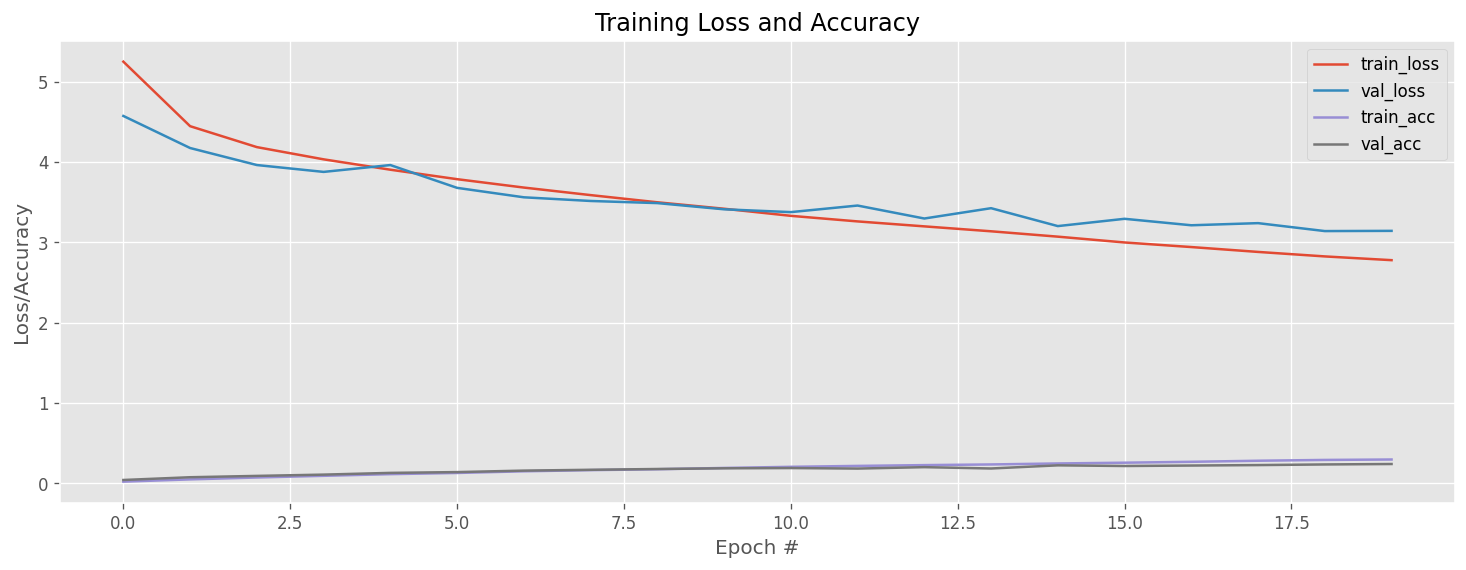

In [95]:
# ---------------------------------------------------------------------
# BASE MODEL -> extrae las características de las imágenes

# Definimos entradas
inputs = Input(shape=(x_train.shape[1], x_train.shape[2], x_train.shape[3]))

# 1 set de capas CONV => RELU => CONV => RELU => POOL
x1 = Conv2D(64, (3, 3), padding="same", activation="relu")(inputs)
x1 = BatchNormalization()(x1)
x1 = Conv2D(64, (3, 3), padding="same", activation="relu")(x1)
x1 = BatchNormalization()(x1)
# x1 = MaxPooling2D(pool_size=(2, 2))(x1)
# x1 = Dropout(0.25)(x1)

# 2 set de capas CONV => RELU => CONV => RELU => POOL
x2 = Conv2D(64, (3, 3), padding="same", activation="relu")(x1)
x2 = BatchNormalization()(x2)
x2 = Conv2D(64, (3, 3), padding="same", activation="relu")(x2)
x2 = BatchNormalization()(x2)
# x2 = MaxPooling2D(pool_size=(2, 2))(x2)
# x2 = Dropout(0.25)(x2)


# 3 set de capas CONV => RELU => CONV => RELU => POOL
x2 = Conv2D(64, (3, 3), padding="same", activation="relu")(x2)
x2 = BatchNormalization()(x2)
x2 = Conv2D(64, (3, 3), padding="same", activation="relu")(x2)
x2 = BatchNormalization()(x2)
# x2 = MaxPooling2D(pool_size=(2, 2))(x2)
# x2 = Dropout(0.25)(x2)

# 4 set de capas CONV => RELU => CONV => RELU => POOL
x2 = Conv2D(64, (3, 3), padding="same", activation="relu")(x2)
x2 = BatchNormalization()(x2)
x2 = Conv2D(64, (3, 3), padding="same", activation="relu")(x2)
x2 = BatchNormalization()(x2)
x2 = MaxPooling2D(pool_size=(2, 2))(x2)
# x2 = Dropout(0.25)(x2)


# 5 set de capas CONV => RELU => CONV => RELU => POOL
x3 = Conv2D(32, (3, 3), padding="same", activation="relu")(x2)
x3 = BatchNormalization()(x3)
x3 = Conv2D(32, (3, 3), padding="same", activation="relu")(x3)
x3 = BatchNormalization()(x3)
# x3 = MaxPooling2D(pool_size=(2, 2))(x3)
# x3 = Dropout(0.25)(x3)

# 6 set de capas CONV => RELU => CONV => RELU => POOL
x4 = Conv2D(32, (3, 3), padding="same", activation="relu")(x3)
x4 = BatchNormalization()(x4)
x4 = Conv2D(32, (3, 3), padding="same", activation="relu")(x4)
x4 = BatchNormalization()(x4)
# x4 = MaxPooling2D(pool_size=(2, 2))(x4)
# x4 = Dropout(0.25)(x4)

# 7 set de capas CONV => RELU => CONV => RELU => POOL
x3 = Conv2D(32, (3, 3), padding="same", activation="relu")(x4)
x3 = BatchNormalization()(x3)
x3 = Conv2D(32, (3, 3), padding="same", activation="relu")(x3)
x3 = BatchNormalization()(x3)
# x3 = MaxPooling2D(pool_size=(2, 2))(x3)
# x3 = Dropout(0.25)(x3)

# 8 set de capas CONV => RELU => CONV => RELU => POOL
x4 = Conv2D(32, (3, 3), padding="same", activation="relu")(x3)
x4 = BatchNormalization()(x4)
x4 = Conv2D(32, (3, 3), padding="same", activation="relu")(x4)
x4 = BatchNormalization()(x4)
x4 = MaxPooling2D(pool_size=(2, 2))(x4)
# x4 = Dropout(0.25)(x4)



# 9 set de capas CONV => RELU => CONV => RELU => POOL
x5 = Conv2D(16, (3, 3), padding="same", activation="relu")(x4)
x5 = BatchNormalization()(x5)
x5 = Conv2D(16, (3, 3), padding="same", activation="relu")(x5)
x5 = BatchNormalization()(x5)
# x5 = MaxPooling2D(pool_size=(2, 2))(x5)
# x5 = Dropout(0.25)(x5)

# 10 set de capas CONV => RELU => CONV => RELU => POOL
x6 = Conv2D(16, (3, 3), padding="same", activation="relu")(x5)
x6 = BatchNormalization()(x6)
x6 = Conv2D(16, (3, 3), padding="same", activation="relu")(x6)
x6 = BatchNormalization()(x6)
# x6 = MaxPooling2D(pool_size=(2, 2))(x6)
# x6 = Dropout(0.25)(x6)


# 11 set de capas CONV => RELU => CONV => RELU => POOL
x8 = Conv2D(8, (3, 3), padding="same", activation="relu")(x6)
x8 = BatchNormalization()(x8)
x8 = Conv2D(8, (3, 3), padding="same", activation="relu")(x8)
x8 = BatchNormalization()(x8)
# x8 = MaxPooling2D(pool_size=(2, 2))(x8)
# x8 = Dropout(0.25)(x8)

# 12 set de capas CONV => RELU => CONV => RELU => POOL
x8 = Conv2D(8, (3, 3), padding="same", activation="relu")(x8)
x8 = BatchNormalization()(x8)
x8 = Conv2D(8, (3, 3), padding="same", activation="relu")(x8)
x8 = BatchNormalization()(x8)
# x8 = MaxPooling2D(pool_size=(2, 2))(x8)
# x8 = Dropout(0.25)(x8)


# ---------------------------------------------------------------------------

# ---------------------------------------------------------------------------
# TOP MODEL -> encargada de separar entre clases, hacer la clasificación

# Primer (y único) set de capas FC => RELU
xfc = Flatten()(x8)
xfc = Dense(512, activation="relu")(xfc)
xfc = BatchNormalization()(xfc)
xfc = Dropout(0.5)(xfc)

# Clasificador softmax
predictions = Dense(100, activation="softmax")(xfc)
# ---------------------------------------------------------------------------

#Creamos el modelo
model = Model(inputs=inputs, outputs=predictions)


model.summary()
# Entrenando la solución con data augmentation
train(x_train, y_train, x_test, y_test, model, BASE_FOLDER)

Aumenta el accuracy así como los parámetros entrenables.

## 5º diseño de la arquitectura** (Accuracy = 50%,  607,396 parámetros entrenables)

Reducimos la profundidad del modelo y aumentamos el número de filtros por capa.

Model: "functional_16"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ input_layer_21 (InputLayer)          │ (None, 32, 32, 3)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_272 (Conv2D)                  │ (None, 32, 32, 128)         │           3,584 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_286              │ (None, 32, 32, 128)         │             512 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_273 (Conv2D)                  │ (None, 32, 32, 128)         │         147,584 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_287              │ (None, 32, 32, 128)         │             512 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_34 (MaxPooling2D)      │ (None, 16, 16, 128)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_32 (Dropout)                 │ (None, 16, 16, 128)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_274 (Conv2D)                  │ (None, 16, 16, 64)          │          73,792 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_288              │ (None, 16, 16, 64)          │             256 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_275 (Conv2D)                  │ (None, 16, 16, 64)          │          36,928 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_289              │ (None, 16, 16, 64)          │             256 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_35 (MaxPooling2D)      │ (None, 8, 8, 64)            │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_33 (Dropout)                 │ (None, 8, 8, 64)            │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_276 (Conv2D)                  │ (None, 8, 8, 32)            │          18,464 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_290              │ (None, 8, 8, 32)            │             128 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_277 (Conv2D)                  │ (None, 8, 8, 32)            │           9,248 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_291              │ (None, 8, 8, 32)            │             128 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_36 (MaxPooling2D)      │ (None, 4, 4, 32)            │               0 │
├──────────────────────────────────────┼─────────────────────────────┼──────────────

 Total params: 607,396 (2.32 MB)

 Trainable params: 605,476 (2.31 MB)

 Non-trainable params: 1,920 (7.50 KB)

[INFO]: Compilando el modelo...
[INFO]: Entrenando la red...
Epoch 1/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 21s 33ms/step - accuracy: 0.0353 - loss: 5.2280 - val_accuracy: 0.1328 - val_loss: 3.8818
Epoch 2/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.1133 - loss: 4.0579 - val_accuracy: 0.1807 - val_loss: 3.5062
Epoch 3/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.1668 - loss: 3.6353 - val_accuracy: 0.1606 - val_loss: 3.6104
Epoch 4/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.2084 - loss: 3.3283 - val_accuracy: 0.2701 - val_loss: 2.9512
Epoch 5/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.2545 - loss: 3.0414 - val_accuracy: 0.2983 - val_loss: 2.8074
Epoch 6/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.2964 - loss: 2.8101 - val_accuracy: 0.3275 - val_loss: 2.7242
Epoch 7/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.3334 - loss: 2.6013 - val_accuracy: 0.3796 - val_loss: 2.4339
Epoch 8/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 2

[INFO]: Evaluando el modelo...
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step
               precision    recall  f1-score   support

        apple       0.57      0.83      0.68       100
aquarium_fish       0.48      0.68      0.56       100
         baby       0.29      0.39      0.33       100
         bear       0.31      0.43      0.36       100
       beaver       0.37      0.11      0.17       100
          bed       0.49      0.56      0.52       100
          bee       0.47      0.55      0.51       100
       beetle       0.48      0.51      0.49       100
      bicycle       0.69      0.71      0.70       100
       bottle       0.83      0.63      0.72       100
         bowl       0.38      0.30      0.34       100
          boy       0.40      0.27      0.32       100
       bridge       0.65      0.45      0.53       100
          bus       0.51      0.50      0.51       100
    butterfly       0.45      0.32      0.37       100
        camel       0.45      0.33      0.38     

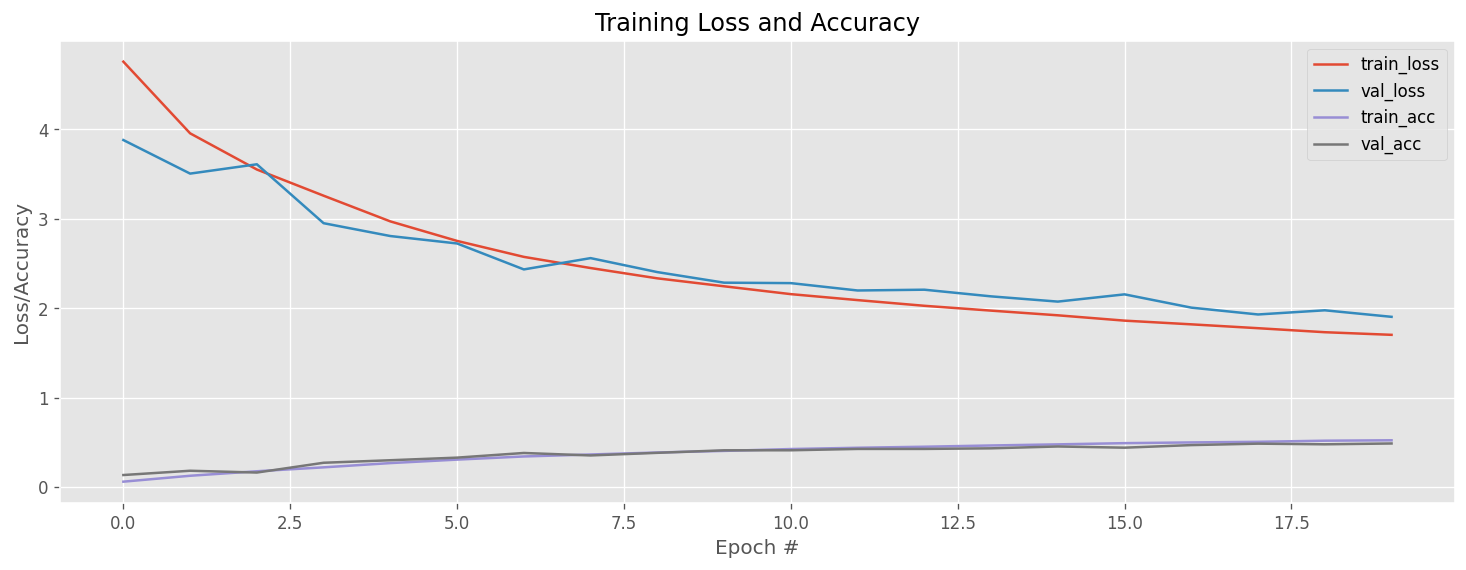

In [119]:
# ---------------------------------------------------------------------
# BASE MODEL -> extrae las características de las imágenes

# Definimos entradas
inputs = Input(shape=(x_train.shape[1], x_train.shape[2], x_train.shape[3]))

# Primer set de capas CONV => RELU => CONV => RELU => POOL
x1 = Conv2D(128, (3, 3), padding="same", activation="relu")(inputs)
x1 = BatchNormalization()(x1)
x1 = Conv2D(128, (3, 3), padding="same", activation="relu")(x1)
x1 = BatchNormalization()(x1)
x1 = MaxPooling2D(pool_size=(2, 2))(x1)
x1 = Dropout(0.25)(x1)

# Segundo set de capas CONV => RELU => CONV => RELU => POOL
x2 = Conv2D(64, (3, 3), padding="same", activation="relu")(x1)
x2 = BatchNormalization()(x2)
x2 = Conv2D(64, (3, 3), padding="same", activation="relu")(x2)
x2 = BatchNormalization()(x2)
x2 = MaxPooling2D(pool_size=(2, 2))(x2)
x2 = Dropout(0.25)(x2)

# Tercer set de capas CONV => RELU => CONV => RELU => POOL
x2 = Conv2D(32, (3, 3), padding="same", activation="relu")(x2)
x2 = BatchNormalization()(x2)
x2 = Conv2D(32, (3, 3), padding="same", activation="relu")(x2)
x2 = BatchNormalization()(x2)
x2 = MaxPooling2D(pool_size=(2, 2))(x2)
x2 = Dropout(0.25)(x2)
# ---------------------------------------------------------------------------

# ---------------------------------------------------------------------------
# TOP MODEL -> encargada de separar entre clases, hacer la clasificación

# Primer (y único) set de capas FC => RELU
xfc = Flatten()(x2)
xfc = Dense(512, activation="relu")(xfc)
xfc = BatchNormalization()(xfc)
xfc = Dropout(0.5)(xfc)

# Clasificador softmax
predictions = Dense(100, activation="softmax")(xfc)
# ---------------------------------------------------------------------------

#Creamos el modelo
model = Model(inputs=inputs, outputs=predictions)

# Entrenando la solución
train(x_train, y_train, x_test, y_test, model, BASE_FOLDER)

Hemos conseguido un accuracy alto reduciendo el número de parámetros entrenables.

## Análisis de resultados.

Los modelos con adición de capas y adición de filtros son los que han dado mejor rendimiento aunque la adición de capas reduce mucho los parámetros entrenables, el accuracy también se reduce mucho.  
Por eso nos quedamos con la arquitectura de adición de filtros ya que aumenta el accuracy al 50% y además reduce considerablemente el número de parámetros entrenables.

## Incluimos learning rate para intentar mejorar el modelo.


Model: "functional_28"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ input_layer_33 (InputLayer)          │ (None, 32, 32, 3)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_466 (Conv2D)                  │ (None, 32, 32, 128)         │           3,584 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_492              │ (None, 32, 32, 128)         │             512 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_467 (Conv2D)                  │ (None, 32, 32, 128)         │         147,584 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_493              │ (None, 32, 32, 128)         │             512 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_116 (MaxPooling2D)     │ (None, 16, 16, 128)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_130 (Dropout)                │ (None, 16, 16, 128)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_468 (Conv2D)                  │ (None, 16, 16, 64)          │          73,792 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_494              │ (None, 16, 16, 64)          │             256 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_469 (Conv2D)                  │ (None, 16, 16, 64)          │          36,928 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_495              │ (None, 16, 16, 64)          │             256 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_117 (MaxPooling2D)     │ (None, 8, 8, 64)            │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_131 (Dropout)                │ (None, 8, 8, 64)            │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_470 (Conv2D)                  │ (None, 8, 8, 32)            │          18,464 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_496              │ (None, 8, 8, 32)            │             128 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_471 (Conv2D)                  │ (None, 8, 8, 32)            │           9,248 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_497              │ (None, 8, 8, 32)            │             128 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_118 (MaxPooling2D)     │ (None, 4, 4, 32)            │               0 │
├──────────────────────────────────────┼─────────────────────────────┼──────────────

 Total params: 607,396 (2.32 MB)

 Trainable params: 605,476 (2.31 MB)

 Non-trainable params: 1,920 (7.50 KB)

[INFO]: Compilando el modelo...
[INFO]: Entrenando la red...
Epoch 1/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 16s 25ms/step - accuracy: 0.0594 - loss: 4.7653 - val_accuracy: 0.0568 - val_loss: 4.6603
Epoch 2/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.1528 - loss: 3.7754 - val_accuracy: 0.1748 - val_loss: 3.5454
Epoch 3/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.2179 - loss: 3.2626 - val_accuracy: 0.2350 - val_loss: 3.1729
Epoch 4/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.2763 - loss: 2.8975 - val_accuracy: 0.2861 - val_loss: 2.9741
Epoch 5/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.3189 - loss: 2.6660 - val_accuracy: 0.3433 - val_loss: 2.6040
Epoch 6/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.3547 - loss: 2.4982 - val_accuracy: 0.3176 - val_loss: 2.7268
Epoch 7/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.3824 - loss: 2.3504 - val_accuracy: 0.3856 - val_loss: 2.4023
Epoch 8/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 2

[INFO]: Evaluando el modelo...
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step
               precision    recall  f1-score   support

        apple       0.63      0.82      0.71       100
aquarium_fish       0.62      0.64      0.63       100
         baby       0.42      0.36      0.39       100
         bear       0.28      0.32      0.30       100
       beaver       0.29      0.15      0.20       100
          bed       0.63      0.47      0.54       100
          bee       0.56      0.56      0.56       100
       beetle       0.42      0.58      0.49       100
      bicycle       0.69      0.63      0.66       100
       bottle       0.93      0.52      0.67       100
         bowl       0.53      0.32      0.40       100
          boy       0.49      0.29      0.36       100
       bridge       0.48      0.59      0.53       100
          bus       0.46      0.53      0.50       100
    butterfly       0.39      0.42      0.41       100
        camel       0.47      0.34      0.40     

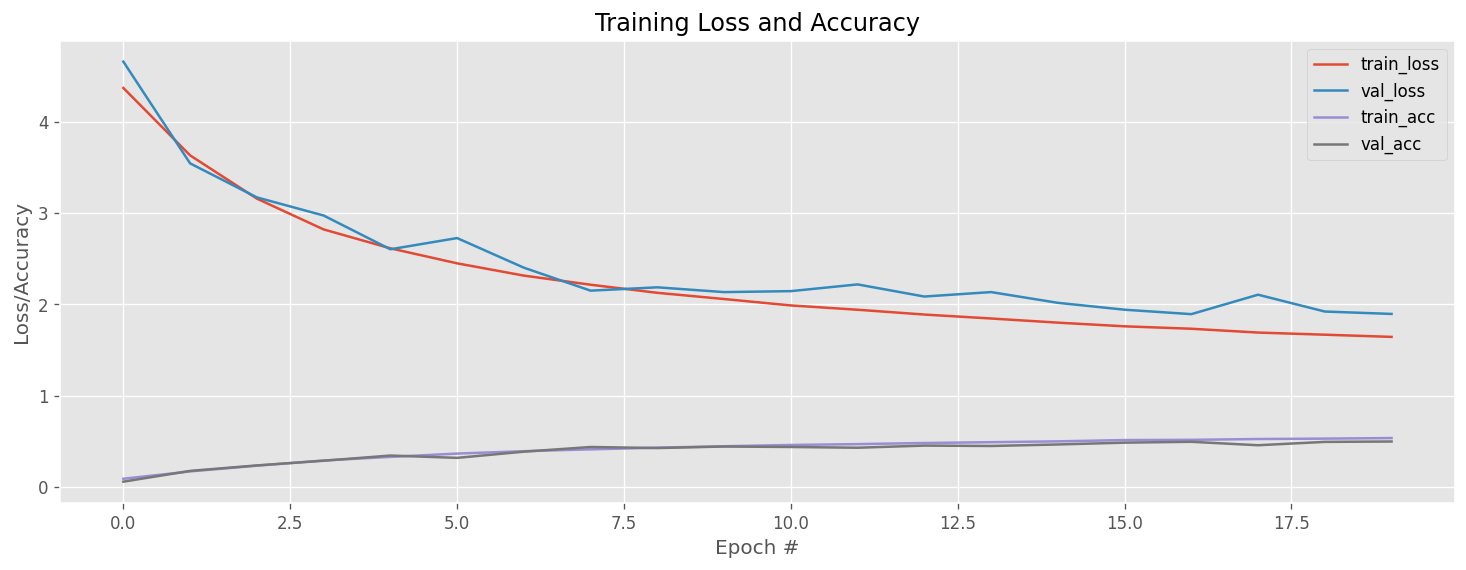

In [131]:
# ---------------------------------------------------------------------
# BASE MODEL -> extrae las características de las imágenes

# Definimos entradas
inputs = Input(shape=(x_train.shape[1], x_train.shape[2], x_train.shape[3]))

# Primer set de capas CONV => RELU => CONV => RELU => POOL
x1 = Conv2D(128, (3, 3), padding="same", activation="relu")(inputs)
x1 = BatchNormalization()(x1)
x1 = Conv2D(128, (3, 3), padding="same", activation="relu")(x1)
x1 = BatchNormalization()(x1)
x1 = MaxPooling2D(pool_size=(2, 2))(x1)
x1 = Dropout(0.25)(x1)

# Segundo set de capas CONV => RELU => CONV => RELU => POOL
x2 = Conv2D(64, (3, 3), padding="same", activation="relu")(x1)
x2 = BatchNormalization()(x2)
x2 = Conv2D(64, (3, 3), padding="same", activation="relu")(x2)
x2 = BatchNormalization()(x2)
x2 = MaxPooling2D(pool_size=(2, 2))(x2)
x2 = Dropout(0.25)(x2)

# Tercer set de capas CONV => RELU => CONV => RELU => POOL
x2 = Conv2D(32, (3, 3), padding="same", activation="relu")(x2)
x2 = BatchNormalization()(x2)
x2 = Conv2D(32, (3, 3), padding="same", activation="relu")(x2)
x2 = BatchNormalization()(x2)
x2 = MaxPooling2D(pool_size=(2, 2))(x2)
x2 = Dropout(0.25)(x2)
# ---------------------------------------------------------------------------

# ---------------------------------------------------------------------------
# TOP MODEL -> encargada de separar entre clases, hacer la clasificación

# Primer (y único) set de capas FC => RELU
xfc = Flatten()(x2)
xfc = Dense(512, activation="relu")(xfc)
xfc = BatchNormalization()(xfc)
xfc = Dropout(0.5)(xfc)

# Clasificador softmax
predictions = Dense(100, activation="softmax")(xfc)
# ---------------------------------------------------------------------------

#Creamos el modelo
model = Model(inputs=inputs, outputs=predictions)

# Entrenando la solución
learn_rate = 0.005
train(x_train, y_train, x_test, y_test, model, BASE_FOLDER, learn_rate)

Probando con varios valores de learning rate obtenemos mejor rendimiento con un learning rate de 0,005 (accuracy 51%)

## Data augmentation. Creación de dos imágenes.

In [135]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator
# Función de entrenamiento aplicando data augmentation
def train_with_datagen(x_train, y_train, x_test, y_test, model_aug, BASE_FOLDER, data_aug_factor, train_datagen, learn_rate=0.005, epochs=20):
    # Resumen del modelo
  model.summary()

  # Entrenando la solución con data augmentation
  train_generator = train_datagen.flow(
    x_train,
    y_train,
    batch_size=128,
    subset= 'training' # (X) INPUT - Definir la partición de entrenamiento
    )

  validation_generator = datagen.flow(
    trainX,
    trainY,
    batch_size=128,
    subset= 'validation' # (X) IMPUT - Definir la partición de validación
    )

In [140]:
# ---------------------------------------------------------------------
# BASE MODEL -> extrae las características de las imágenes

# Definimos entradas
inputs = Input(shape=(x_train.shape[1], x_train.shape[2], x_train.shape[3]))

# Primer set de capas CONV => RELU => CONV => RELU => POOL
x1 = Conv2D(128, (3, 3), padding="same", activation="relu")(inputs)
x1 = BatchNormalization()(x1)
x1 = Conv2D(128, (3, 3), padding="same", activation="relu")(x1)
x1 = BatchNormalization()(x1)
x1 = MaxPooling2D(pool_size=(2, 2))(x1)
x1 = Dropout(0.25)(x1)

# Segundo set de capas CONV => RELU => CONV => RELU => POOL
x2 = Conv2D(64, (3, 3), padding="same", activation="relu")(x1)
x2 = BatchNormalization()(x2)
x2 = Conv2D(64, (3, 3), padding="same", activation="relu")(x2)
x2 = BatchNormalization()(x2)
x2 = MaxPooling2D(pool_size=(2, 2))(x2)
x2 = Dropout(0.25)(x2)

# Tercer set de capas CONV => RELU => CONV => RELU => POOL
x2 = Conv2D(32, (3, 3), padding="same", activation="relu")(x2)
x2 = BatchNormalization()(x2)
x2 = Conv2D(32, (3, 3), padding="same", activation="relu")(x2)
x2 = BatchNormalization()(x2)
x2 = MaxPooling2D(pool_size=(2, 2))(x2)
x2 = Dropout(0.25)(x2)
# ---------------------------------------------------------------------------

# ---------------------------------------------------------------------------
# TOP MODEL -> encargada de separar entre clases, hacer la clasificación

# Primer (y único) set de capas FC => RELU
xfc = Flatten()(x2)
xfc = Dense(512, activation="relu")(xfc)
xfc = BatchNormalization()(xfc)
xfc = Dropout(0.5)(xfc)

# Clasificador softmax
predictions = Dense(100, activation="softmax")(xfc)
# ---------------------------------------------------------------------------

#Creamos el modelo
model = Model(inputs=inputs, outputs=predictions)

# Entrenando la solución con data augmentation
train_datagen = ImageDataGenerator(
    rotation_range=15,
    width_shift_range=0.1,
    height_shift_range=0.1,
    horizontal_flip=True,
    validation_split=0.2
    )

data_aug_factor = 2 # Creación de 2 muestras sintéticas por cada muestra real
train_with_datagen(x_train, y_train, x_test, y_test, model, BASE_FOLDER, data_aug_factor, train_datagen, learn_rate)


Model: "functional_34"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ input_layer_39 (InputLayer)          │ (None, 32, 32, 3)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_502 (Conv2D)                  │ (None, 32, 32, 128)         │           3,584 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_534              │ (None, 32, 32, 128)         │             512 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_503 (Conv2D)                  │ (None, 32, 32, 128)         │         147,584 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_535              │ (None, 32, 32, 128)         │             512 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_134 (MaxPooling2D)     │ (None, 16, 16, 128)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_154 (Dropout)                │ (None, 16, 16, 128)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_504 (Conv2D)                  │ (None, 16, 16, 64)          │          73,792 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_536              │ (None, 16, 16, 64)          │             256 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_505 (Conv2D)                  │ (None, 16, 16, 64)          │          36,928 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_537              │ (None, 16, 16, 64)          │             256 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_135 (MaxPooling2D)     │ (None, 8, 8, 64)            │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_155 (Dropout)                │ (None, 8, 8, 64)            │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_506 (Conv2D)                  │ (None, 8, 8, 32)            │          18,464 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_538              │ (None, 8, 8, 32)            │             128 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_507 (Conv2D)                  │ (None, 8, 8, 32)            │           9,248 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_539              │ (None, 8, 8, 32)            │             128 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_136 (MaxPooling2D)     │ (None, 4, 4, 32)            │               0 │
├──────────────────────────────────────┼─────────────────────────────┼──────────────

 Total params: 607,396 (2.32 MB)

 Trainable params: 605,476 (2.31 MB)

 Non-trainable params: 1,920 (7.50 KB)

NameError: name 'datagen' is not defined